In [1]:
import re
import os
import copy
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datasets import load_dataset
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModel, logging
from torch.optim import AdamW
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, accuracy_score
from tqdm.auto import tqdm

In [2]:
dataset = load_dataset("Tobi-Bueck/customer-support-tickets")
df = pd.DataFrame(dataset['train'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [3]:
def read_idx_file(filepath):
    with open(filepath, 'r') as f:
        indices = [int(line.strip()) for line in f if line.strip()]
    return indices

train_idx = read_idx_file('train_idx.txt')
val_idx = read_idx_file('val_idx.txt')
test_idx = read_idx_file('test_idx.txt')

print(f"Train: {len(train_idx)}")
print(f"Val: {len(val_idx)}")
print(f"Test: {len(test_idx)}")
print(f"Total: {len(train_idx) + len(val_idx) + len(test_idx)}")

Train: 49412
Val: 6176
Test: 6177
Total: 61765


In [4]:
df_train = df.iloc[train_idx].reset_index(drop=True)
df_val = df.iloc[val_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

print(f"Train shape: {df_train.shape}")
print(f"Val shape: {df_val.shape}")
print(f"Test shape: {df_test.shape}")

Train shape: (49412, 16)
Val shape: (6176, 16)
Test shape: (6177, 16)


In [5]:
for df_split in [df_train, df_val, df_test]:
    df_split['text'] = df_split['subject'].fillna('') + " " + df_split['body'].fillna('')


#EDA: распределение классов queue, длины текстов.

In [6]:
eda_df = df_train.copy()
eda_df

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,text
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None,Wesentlicher Sicherheitsvorfall Sehr geehrtes ...
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None,"Account Disruption Dear Customer Support Team,..."
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None,Query About Smart Home System Integration Feat...
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None,Inquiry Regarding Invoice Details Dear Custome...
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None,Question About Marketing Agency Software Compa...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49407,Assistance Needed for IFTTT Docker Integration,I am facing integration problems with IFTTT Do...,I would be happy to assist with the IFTTT Dock...,Problem,Technical Support,low,en,NaN,Integration,Disruption,Performance,IT,Tech Support,None,None,None,Assistance Needed for IFTTT Docker Integration...
49408,Bitten um Unterstützung bei der Integration,"Sehr geehrte Kundenservice, ich möchte die Int...","Sehr geehrte [Name], vielen Dank für Ihren Kon...",Change,Technical Support,medium,de,NaN,Integration,Feature,Documentation,Tech Support,None,None,None,None,Bitten um Unterstützung bei der Integration Se...
49409,None,"Hello Customer Support, I am inquiring about t...",We will send you detailed information on plans...,Request,Billing and Payments,low,en,NaN,Billing,Payment,Feature,Feedback,Sales,Lead,None,None,"Hello Customer Support, I am inquiring about ..."
49410,Hilfe bei digitalen Strategie-Problemen,Die Qualität unserer digitalen Strategie-Bearb...,Um den digitalen Strategie-Impuls zu überprüfe...,Incident,Product Support,high,de,NaN,Feedback,Performance,IT,Tech Support,None,None,None,None,Hilfe bei digitalen Strategie-Problemen Die Qu...


In [7]:
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49412 entries, 0 to 49411
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   45144 non-null  object 
 1   body      49410 non-null  object 
 2   answer    38893 non-null  object 
 3   type      38904 non-null  object 
 4   queue     49412 non-null  object 
 5   priority  49412 non-null  object 
 6   language  49412 non-null  object 
 7   version   22924 non-null  float64
 8   tag_1     38904 non-null  object 
 9   tag_2     38857 non-null  object 
 10  tag_3     38722 non-null  object 
 11  tag_4     35212 non-null  object 
 12  tag_5     22118 non-null  object 
 13  tag_6     10580 non-null  object 
 14  tag_7     4757 non-null   object 
 15  tag_8     1981 non-null   object 
 16  text      49412 non-null  object 
dtypes: float64(1), object(16)
memory usage: 6.4+ MB


In [8]:
eda_df.isna().sum()

,0
subject,4268
body,2
answer,10519
type,10508
queue,0
priority,0
language,0
version,26488
tag_1,10508
tag_2,10555


In [9]:
eda_df.duplicated().sum()

np.int64(0)

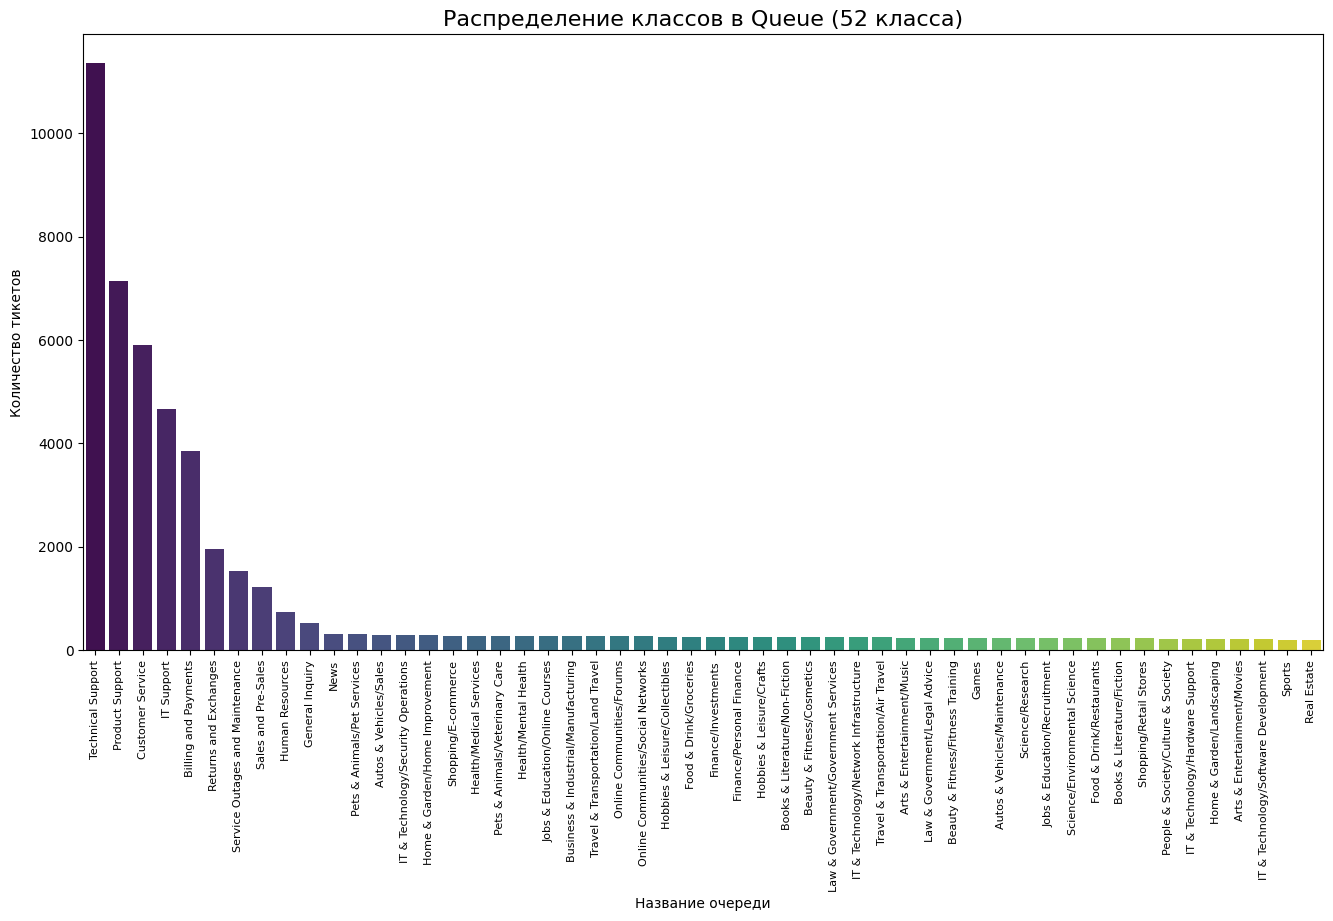

Самый частый класс: 'Technical Support' (11354 примеров)
Самый редкий класс: 'Real Estate' (187 примеров)


In [10]:
plt.figure(figsize=(16, 8))
queue_counts = eda_df['queue'].value_counts()

sns.barplot(x=queue_counts.index, y=queue_counts.values, hue=queue_counts.index, palette="viridis")
plt.title("Распределение классов в Queue (52 класса)", fontsize=16)
plt.xticks(rotation=90, fontsize=8)
plt.ylabel("Количество тикетов")
plt.xlabel("Название очереди")
plt.show()

print(f"Самый частый класс: '{queue_counts.index[0]}' ({queue_counts.values[0]} примеров)")
print(f"Самый редкий класс: '{queue_counts.index[-1]}' ({queue_counts.values[-1]} примеров)")

In [11]:
eda_df['type']=df_train['type'].fillna('Unknown').values

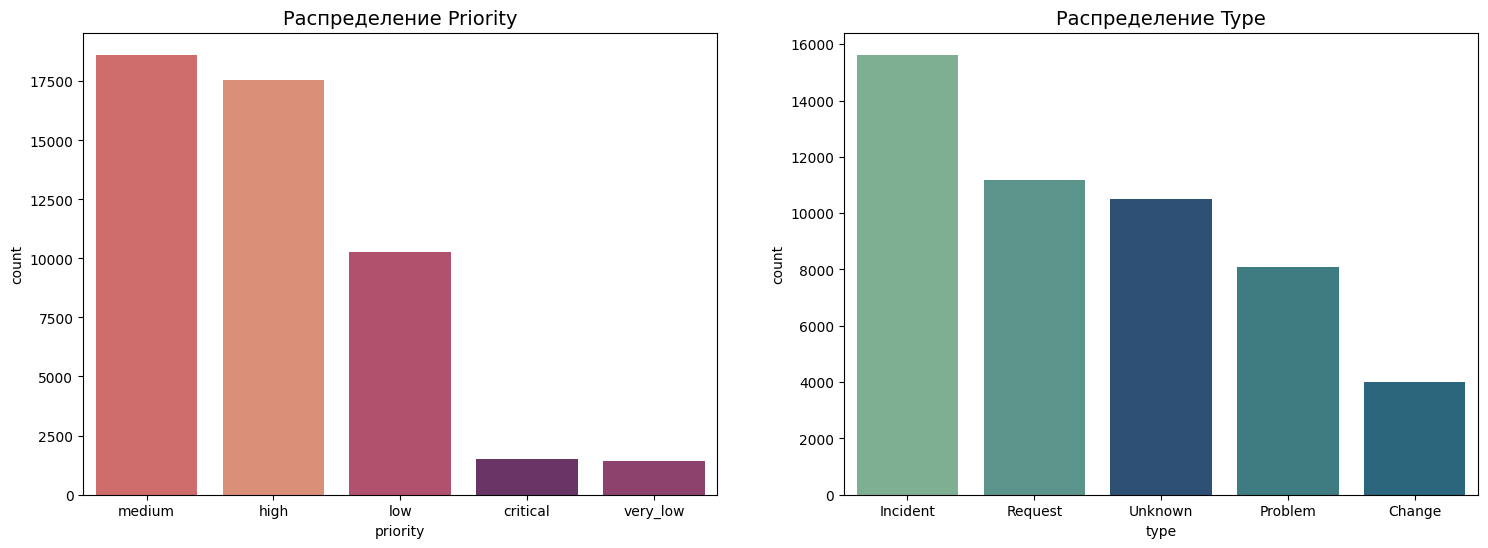

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.countplot(data=eda_df, x='priority',hue='priority', ax=axes[0], palette="flare", order=eda_df['priority'].value_counts().index)
axes[0].set_title("Распределение Priority", fontsize=14)

sns.countplot(data=eda_df, x='type',hue='type', ax=axes[1], palette="crest",order=eda_df['type'].value_counts().index)
axes[1].set_title("Распределение Type", fontsize=14)

plt.show()


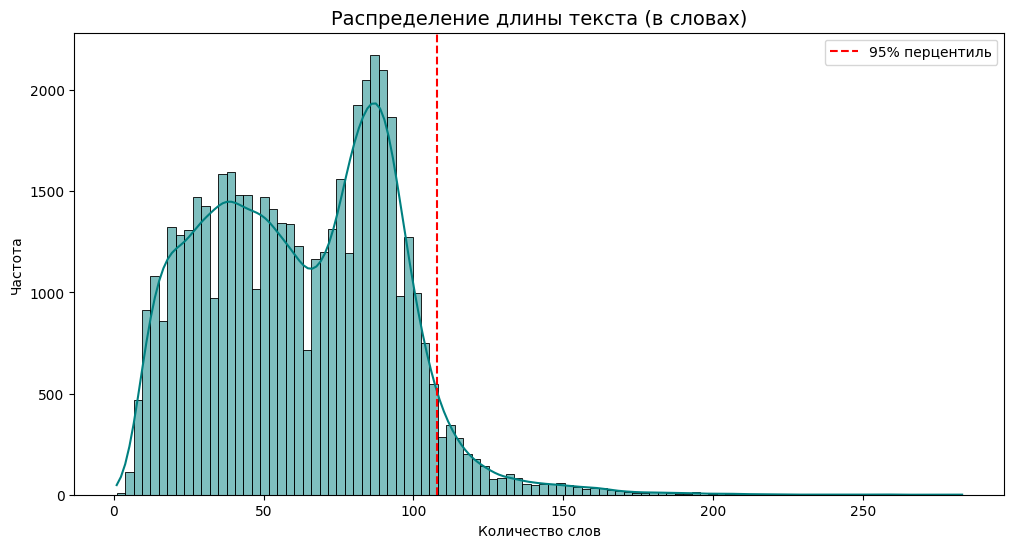

95% тикетов имеют длину до 108 слов.


In [13]:
eda_df['word_len'] = eda_df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 6))
sns.histplot(eda_df['word_len'], bins=100, kde=True, color='teal')
plt.axvline(eda_df['word_len'].quantile(0.95), color='red', linestyle='--', label='95% перцентиль')
plt.title("Распределение длины текста (в словах)", fontsize=14)
plt.xlabel("Количество слов")
plt.ylabel("Частота")
plt.legend()
plt.show()

print(f"95% тикетов имеют длину до {int(eda_df['word_len'].quantile(0.95))} слов.")

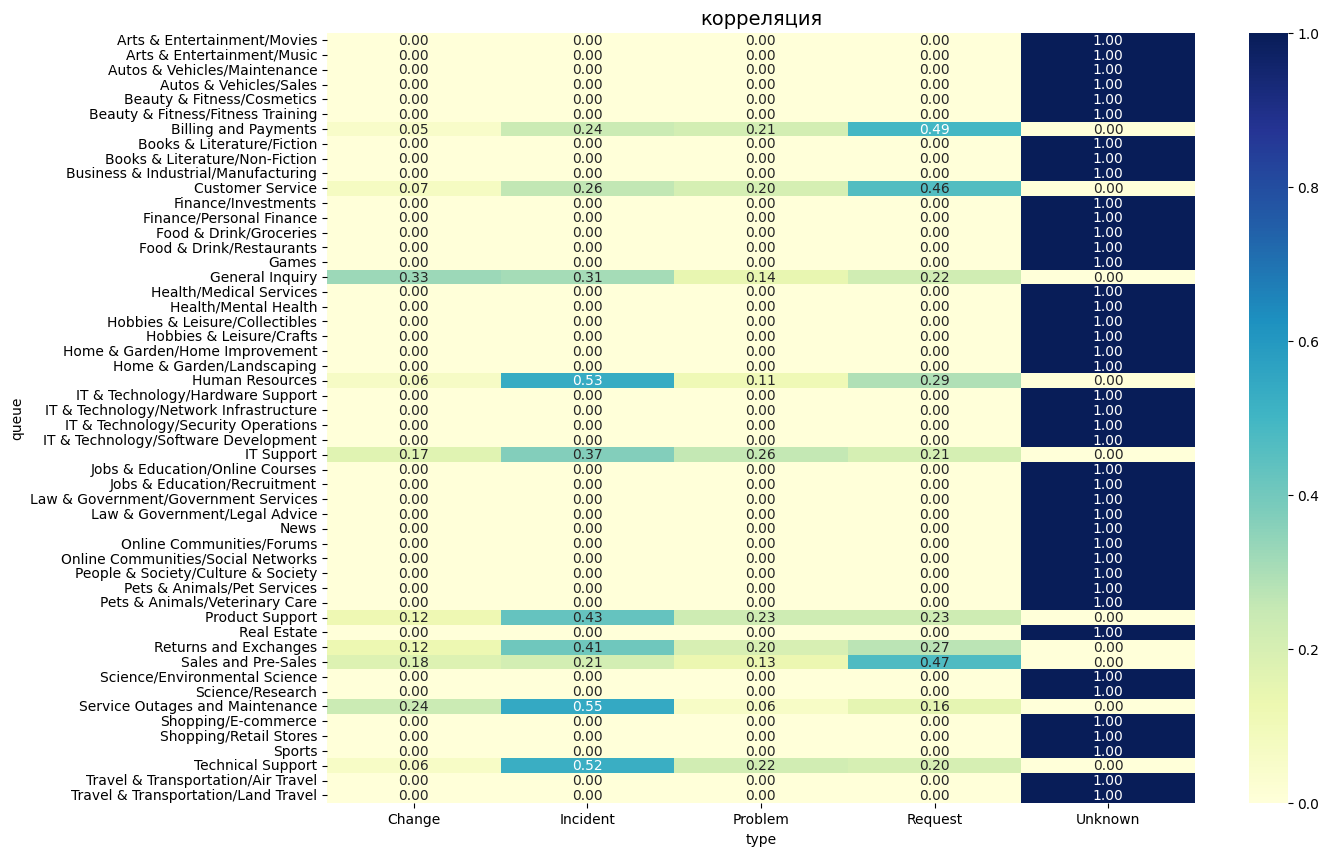

In [14]:
top_queues = eda_df['queue'].value_counts().index
subset = eda_df[eda_df['queue'].isin(top_queues)]

plt.figure(figsize=(14, 10))
ct = pd.crosstab(subset['queue'], subset['type'], normalize='index')
sns.heatmap(ct, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("корреляция", fontsize=14)
plt.show()

In [15]:
eda_df['subject_len'] = eda_df['subject'].str.len()
eda_df['body_len'] = eda_df['body'].str.len()

print(f"Средняя длина subject: {eda_df['subject_len'].mean():.1f} символов")
print(f"Средняя длина body: {eda_df['body_len'].mean():.1f} символов")

empty_bodies = eda_df['body'].isna().sum()
print(f"Тикетов без тела сообщения: {empty_bodies}")

Средняя длина subject: 47.4 символов
Средняя длина body: 419.4 символов
Тикетов без тела сообщения: 2


In [16]:
has_html = eda_df['text'].str.contains('<[^>]+>').sum()
print(f"Тикетов с HTML-разметкой: {has_html}")

has_links = eda_df['text'].str.contains('http').sum()
print(f"Тикетов со ссылками: {has_links}")

Тикетов с HTML-разметкой: 5793
Тикетов со ссылками: 0


#Baseline: TF-IDF + линейная модель для queue (macro-F1 и accuracy).

In [17]:
def clean_text(text):
    text = re.sub(r'<[^>]+>', ' ', str(text))
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

df_train['type'] = df_train['type'].fillna('Unknown')
df_val['type'] = df_val['type'].fillna('Unknown')
df_test['type'] = df_test['type'].fillna('Unknown')

X_train_raw = df_train['text'].apply(clean_text)
X_val_raw   = df_val['text'].apply(clean_text)
X_test_raw  = df_test['text'].apply(clean_text)

tfidf = TfidfVectorizer(max_features=100000, ngram_range=(1, 2), stop_words="english",
    min_df=2)

X_train = tfidf.fit_transform(X_train_raw)
X_val   = tfidf.transform(X_val_raw)
X_test  = tfidf.transform(X_test_raw)

best_models = {}

def train_and_validate(target_name):
    y_train = df_train[target_name]
    y_val   = df_val[target_name]

    svc = LinearSVC(class_weight='balanced', random_state=42, C=1, max_iter=2000)
    model = CalibratedClassifierCV(svc, cv=3)

    model.fit(X_train, y_train)

    val_preds = model.predict(X_val)
    val_f1 = f1_score(y_val, val_preds, average='macro')
    val_acc = accuracy_score(y_val, val_preds)
    best_models[target_name] = model

    return val_f1, val_acc

f1_q, acc_q = train_and_validate('queue')
f1_p, acc_p = train_and_validate('priority')
f1_t, acc_t = train_and_validate('type')
final_score = 0.70 * f1_q + 0.15 * acc_p + 0.15 * acc_t
print(f"тест Macro-F1 (Queue): {f1_q:.4f}")
print(f"тест Accuracy (Queue): {acc_q:.4f}")
print(f"тест Accuracy (Priority): {acc_p:.4f}")
print(f"тест Accuracy (Type): {acc_t:.4f}")
print(f"итоговый score: {final_score:.4f}")


тест Macro-F1 (Queue): 0.8880
тест Accuracy (Queue): 0.6645
тест Accuracy (Priority): 0.6979
тест Accuracy (Type): 0.8852
итоговый score: 0.8590


In [18]:
y_test_q = df_test['queue']
y_test_p = df_test['priority']
y_test_t = df_test['type']

preds_q = best_models['queue'].predict(X_test)
preds_p = best_models['priority'].predict(X_test)
preds_t = best_models['type'].predict(X_test)

f1_q_test = f1_score(y_test_q, preds_q, average='macro')
acc_p_test = accuracy_score(y_test_p, preds_p)
acc_t_test = accuracy_score(y_test_t, preds_t)
acc_q_test = accuracy_score(y_test_q, preds_q)

final_score = 0.70 * f1_q_test + 0.15 * acc_p_test + 0.15 * acc_t_test

print(f"тест Macro-F1 (Queue): {f1_q_test:.4f}")
print(f"тест Accuracy (Queue): {acc_q_test:.4f}")
print(f"тестAccuracy (Priority): {acc_p_test:.4f}")
print(f"тест Accuracy (Type): {acc_t_test:.4f}")
print(f"итоговый score: {final_score:.4f}")

тест Macro-F1 (Queue): 0.8850
тест Accuracy (Queue): 0.6612
тестAccuracy (Priority): 0.6864
тест Accuracy (Type): 0.8899
итоговый score: 0.8560


#Transformer fine-tuning на multitask (queue, priority, type)

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
       torch.cuda.manual_seed(seed)
       torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

logging.set_verbosity_error()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
max_len = 128
batch_size = 64
epochs = 18
learning_rate = 3e-5

def clean_text(text):
    text = re.sub(r'<[^>]+>', ' ', str(text))
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

for df in [df_train, df_val, df_test]:
    df['type'] = df['type'].fillna('unknown')
    df['text'] = df['text'].apply(clean_text)

le_q, le_p, le_t = LabelEncoder(), LabelEncoder(), LabelEncoder()
all_data = pd.concat([df_train, df_val, df_test])

le_q.fit(all_data['queue'])
le_p.fit(all_data['priority'])
le_t.fit(all_data['type'])

for df in [df_train, df_val, df_test]:
    df['q_id'] = le_q.transform(df['queue'])
    df['p_id'] = le_p.transform(df['priority'])
    df['t_id'] = le_t.transform(df['type'])

num_q, num_p, num_t = len(le_q.classes_), len(le_p.classes_), len(le_t.classes_)

tokenizer = AutoTokenizer.from_pretrained(model_name)

def fast_tokenize(texts):
    return tokenizer(
        texts.tolist(),
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

train_enc = fast_tokenize(df_train['text'])
val_enc = fast_tokenize(df_val['text'])
test_enc = fast_tokenize(df_test['text'])

class FastDataset(Dataset):
    def __init__(self, enc, q, p, t):
        self.enc = enc
        self.q, self.p, self.t = torch.tensor(q.values), torch.tensor(p.values), torch.tensor(t.values)
    def __len__(self): return len(self.q)
    def __getitem__(self, i):
        return {'ids': self.enc['input_ids'][i], 'mask': self.enc['attention_mask'][i],
                'q': self.q[i], 'p': self.p[i], 't': self.t[i]}

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(FastDataset(train_enc, df_train['q_id'], df_train['p_id'], df_train['t_id']), batch_size=batch_size, shuffle=True, worker_init_fn=seed_worker, generator=g)
val_loader = DataLoader(FastDataset(val_enc, df_val['q_id'], df_val['p_id'], df_val['t_id']), batch_size=batch_size, worker_init_fn=seed_worker, generator=g)
test_loader = DataLoader(FastDataset(test_enc, df_test['q_id'], df_test['p_id'], df_test['t_id']), batch_size=batch_size, worker_init_fn=seed_worker, generator=g)

class TicketModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        for param in self.backbone.embeddings.parameters(): param.requires_grad = False
        for param in self.backbone.encoder.layer[:6].parameters(): param.requires_grad = False

        h = self.backbone.config.hidden_size
        self.q_head = nn.Sequential(nn.Linear(h, 256), nn.ReLU(), nn.Dropout(0.2), nn.Linear(256, num_q))
        self.p_head = nn.Linear(h, num_p)
        self.t_head = nn.Linear(h, num_t)

    def forward(self, ids, mask):
        out = self.backbone(ids, mask)
        embeddings = out.last_hidden_state
        mask_expanded = mask.unsqueeze(-1).expand(embeddings.size()).float()
        pooled = torch.sum(embeddings * mask_expanded, 1) / torch.clamp(mask_expanded.sum(1), min=1e-9)
        return {'q': self.q_head(pooled), 'p': self.p_head(pooled), 't': self.t_head(pooled)}

model = TicketModel().to(device)
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)
scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))
criterion = nn.CrossEntropyLoss()

best_val_score = 0.0
best_model_weights = None

for epoch in range(epochs):
    model.train()
    for b in tqdm(train_loader, desc=f"epoch {epoch+1}"):
        optimizer.zero_grad()
        ids, mask = b['ids'].to(device), b['mask'].to(device)
        with torch.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            out = model(ids, mask)
            l_q = criterion(out['q'], b['q'].to(device))
            l_p = criterion(out['p'], b['p'].to(device))
            l_t = criterion(out['t'], b['t'].to(device))
            loss = l_q * 1.0 + l_p * 0.2 + l_t * 0.2
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

    model.eval()
    val_q_t, val_q_p, val_p_t, val_p_p, val_t_t, val_t_p = [], [], [], [], [], []
    with torch.no_grad():
        for b in val_loader:
            ids, mask = b['ids'].to(device), b['mask'].to(device)
            with torch.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                out = model(ids, mask)

            val_q_t.extend(b['q'].numpy())
            val_q_p.extend(torch.max(out['q'], 1)[1].cpu().numpy())
            val_p_t.extend(b['p'].numpy())
            val_p_p.extend(torch.max(out['p'], 1)[1].cpu().numpy())
            val_t_t.extend(b['t'].numpy())
            val_t_p.extend(torch.max(out['t'], 1)[1].cpu().numpy())

    val_f1_q = f1_score(val_q_t, val_q_p, average='macro')
    val_acc_p = accuracy_score(val_p_t, val_p_p)
    val_acc_t = accuracy_score(val_t_t, val_t_p)

    current_val_score = 0.70 * val_f1_q + 0.15 * val_acc_p + 0.15 * val_acc_t
    print(f"validation score: {current_val_score:.4f} (macro-f1 queue: {val_f1_q:.4f})")

    if current_val_score > best_val_score:
        best_val_score = current_val_score
        best_model_weights = copy.deepcopy(model.state_dict())

model.load_state_dict(best_model_weights)

def get_metrics(loader):
    model.eval()
    q_t, q_p, q_c, p_t, p_p, t_t, t_p = [], [], [], [], [], [], []
    with torch.no_grad():
        for b in loader:
            ids, mask = b['ids'].to(device), b['mask'].to(device)
            with torch.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                out = model(ids, mask)
            probs_q = F.softmax(out['q'], dim=1)
            conf, pred_q = torch.max(probs_q, dim=1)
            q_t.extend(b['q'].numpy()); q_p.extend(pred_q.cpu().numpy()); q_c.extend(conf.cpu().numpy())
            p_t.extend(b['p'].numpy()); p_p.extend(torch.max(out['p'], 1)[1].cpu().numpy())
            t_t.extend(b['t'].numpy()); t_p.extend(torch.max(out['t'], 1)[1].cpu().numpy())
    return q_t, q_p, q_c, p_t, p_p, t_t, t_p

qt, qp, qc, pt, pp, tt, tp = get_metrics(test_loader)

f1_q = f1_score(qt, qp, average='macro')
acc_p = accuracy_score(pt, pp)
acc_t = accuracy_score(tt, tp)
acc_q = accuracy_score(qt, qp)

final_score = 0.70 * f1_q + 0.15 * acc_p + 0.15 * acc_t



In [20]:
print(f"macro-f1 queue: {f1_q:.4f}")
print(f"accuracy queue: {acc_q:.4f}")
print(f"accuracy priority: {acc_p:.4f}")
print(f"accuracy type: {acc_t:.4f}")
print(f"!!!final test score!!!: {final_score:.4f}")

macro-f1 queue: 0.9067
accuracy queue: 0.7253
accuracy priority: 0.6128
accuracy type: 0.8637
!!!final test score!!!: 0.8561
